В данной работе проводится сравнения результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель кинематического упрочнения - **BKIN**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress


real_experiment_data_folder = r"D:\Users\complex_deformations\P29\experimental_vint"
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.


In [2]:
from core.reader import read_ansys_csv

numerical_experiment_bkin = read_ansys_csv("bkin.csv")

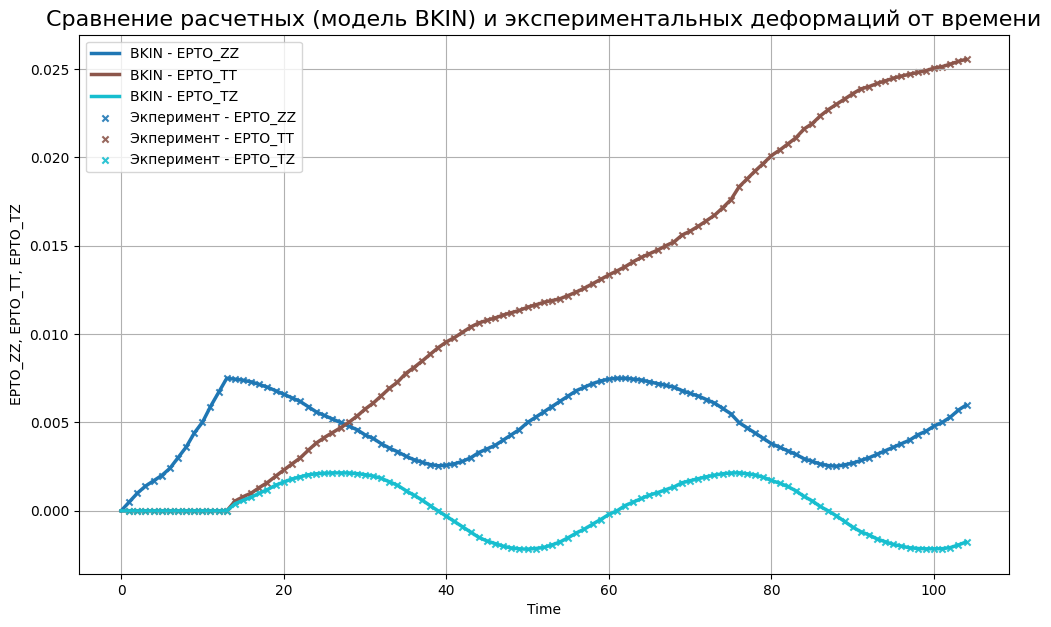

In [3]:
from core.visualizer import plot_xy

model_name = "BKIN"
plot_xy([
        (model_name, numerical_experiment_bkin)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

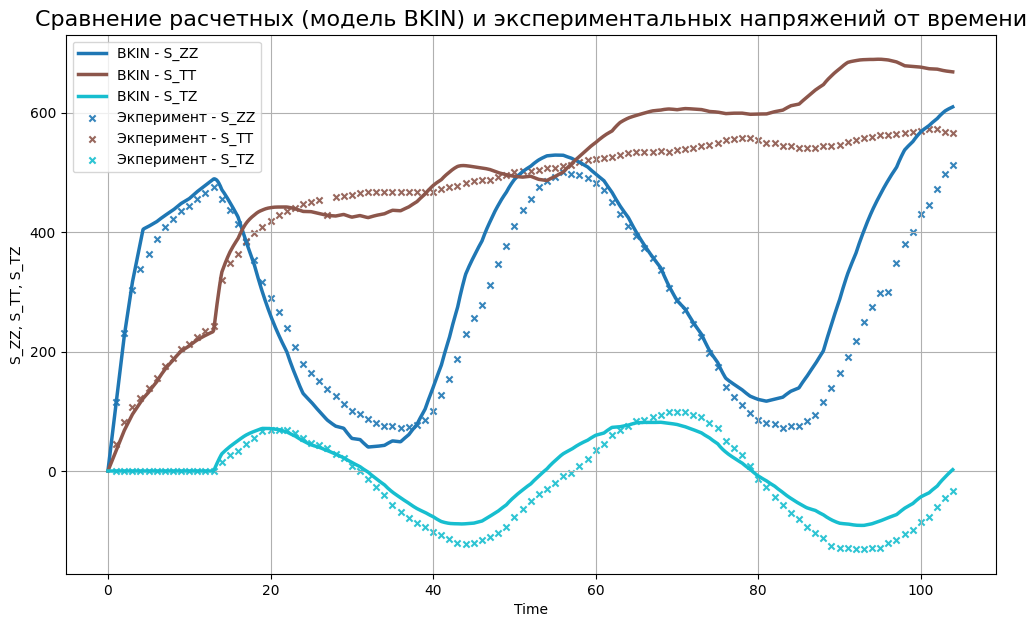

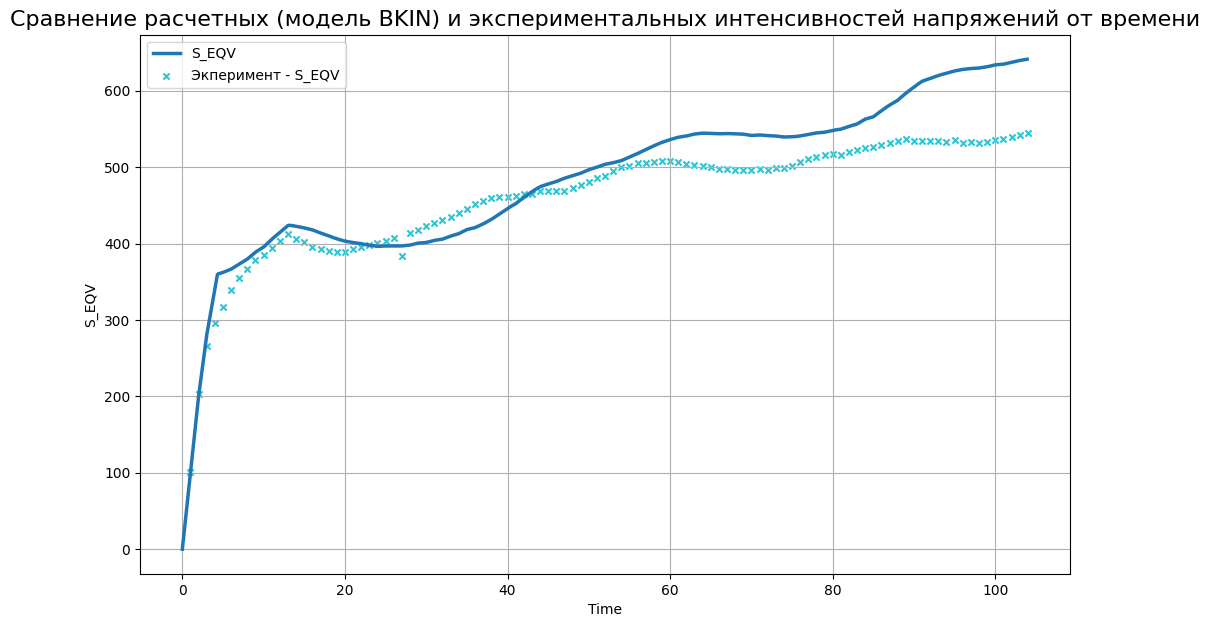

In [4]:
plot_xy([
        (model_name, numerical_experiment_bkin)
    ],
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_bkin)
    ],
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

### Сравнительный анализ векторов напряжений Ильюшина

Для оценки достоверности численной модели проведем сравнение вектора напряжений $\vec{\sigma}_{mc}$ (ANSYS) и вектора $\vec{\sigma}_{exp}$ (эксперимент) в пятимерном пространстве напряжений Ильюшина. Расчет выполнен по следующим критериям:

#### 1. Угловое рассогласование ($\varphi$)
Определяет точность предсказания **направления** процесса деформирования. Угол между векторами вычисляется через скалярное произведение:
$$\varphi = \arccos\left(\frac{\vec{\sigma}_{mc} \cdot \vec{\sigma}_{exp}}{|\vec{\sigma}_{mc}| \cdot |\vec{\sigma}_{exp}|}\right)$$
*Значение $\varphi = 0$ соответствует полному совпадению направлений векторов.*

#### 2. Относительная погрешность модуля ($\text{Error}$)
Определяет точность расчета **амплитуды** (интенсивности) напряжений:
$$\text{Error} = \frac{|\vec{\sigma}_{mc} - \vec{\sigma}_{exp}|}{|\vec{\sigma}_{mc}|}$$

In [5]:
split_time_exp = 14.0

df_exp_stage2 = real_experiment[real_experiment["Time"] > split_time_exp].copy()
df_exp_stage2.reset_index(drop=True, inplace=True)
df_exp_stage2["Time_Local"] = df_exp_stage2["Time"] - df_exp_stage2["Time"].iloc[0]
df_exp_stage2["Sigma_Mean"] = (df_exp_stage2["S_ZZ"] + df_exp_stage2["S_TT"]) / 3.0

numerical_experiment_stage2 = numerical_experiment_bkin[numerical_experiment_bkin["Time"] > split_time_exp].copy()
numerical_experiment_stage2.reset_index(drop=True, inplace=True)
numerical_experiment_stage2["Time_Local"] = numerical_experiment_stage2["Time"] - numerical_experiment_stage2["Time"].iloc[0]

In [6]:
from core.calculations import calculate_stress_vector


sig_1, sig_2, sig_3 = calculate_stress_vector(df_exp_stage2)
df_exp_stage2["Sig_1"] = sig_1
df_exp_stage2["Sig_2"] = sig_2
df_exp_stage2["Sig_3"] = sig_3

sig_1, sig_2, sig_3 = calculate_stress_vector(numerical_experiment_stage2)
numerical_experiment_stage2["Sig_1"] = sig_1
numerical_experiment_stage2["Sig_2"] = sig_2
numerical_experiment_stage2["Sig_3"] = sig_3

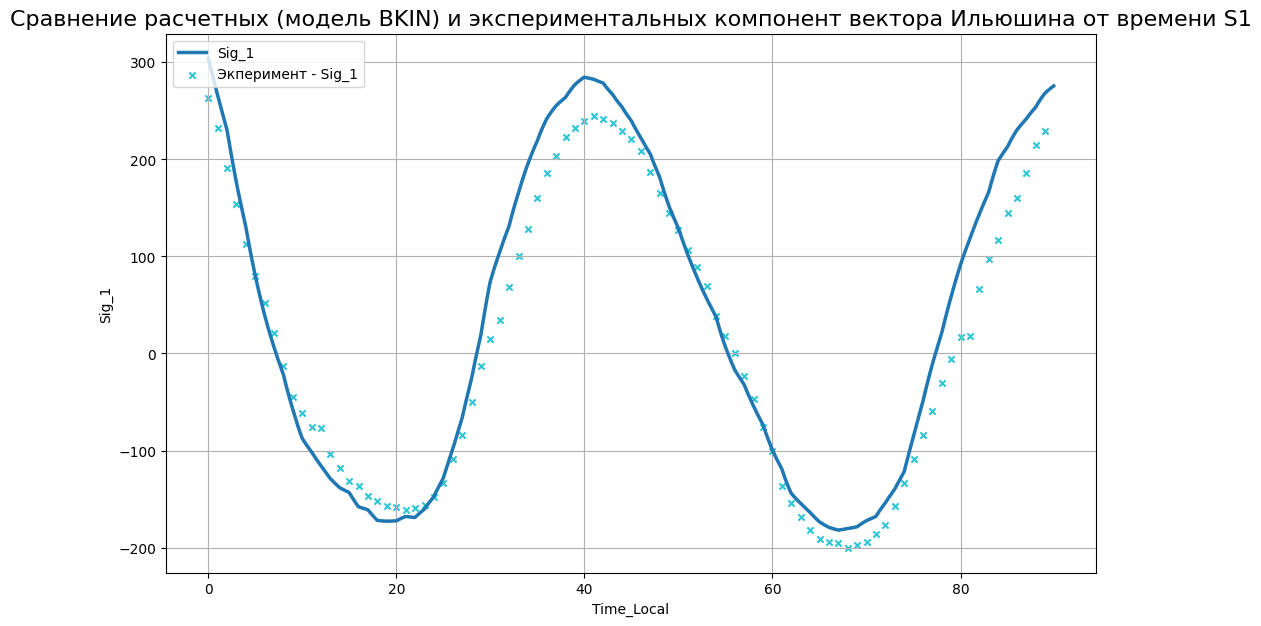

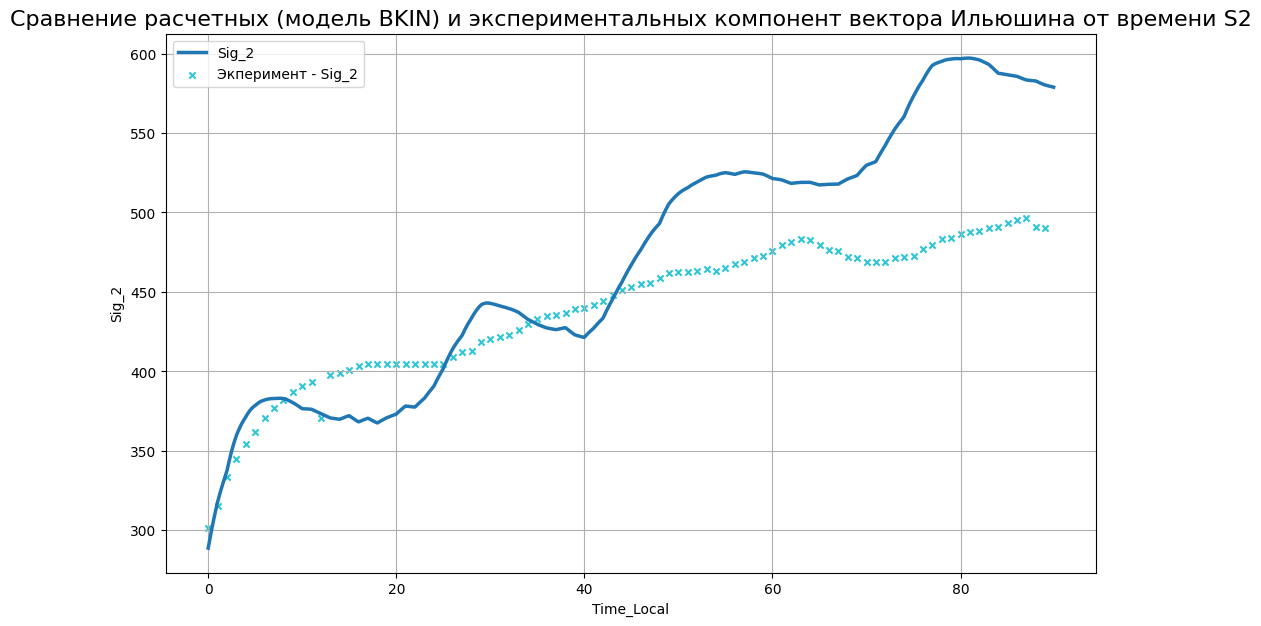

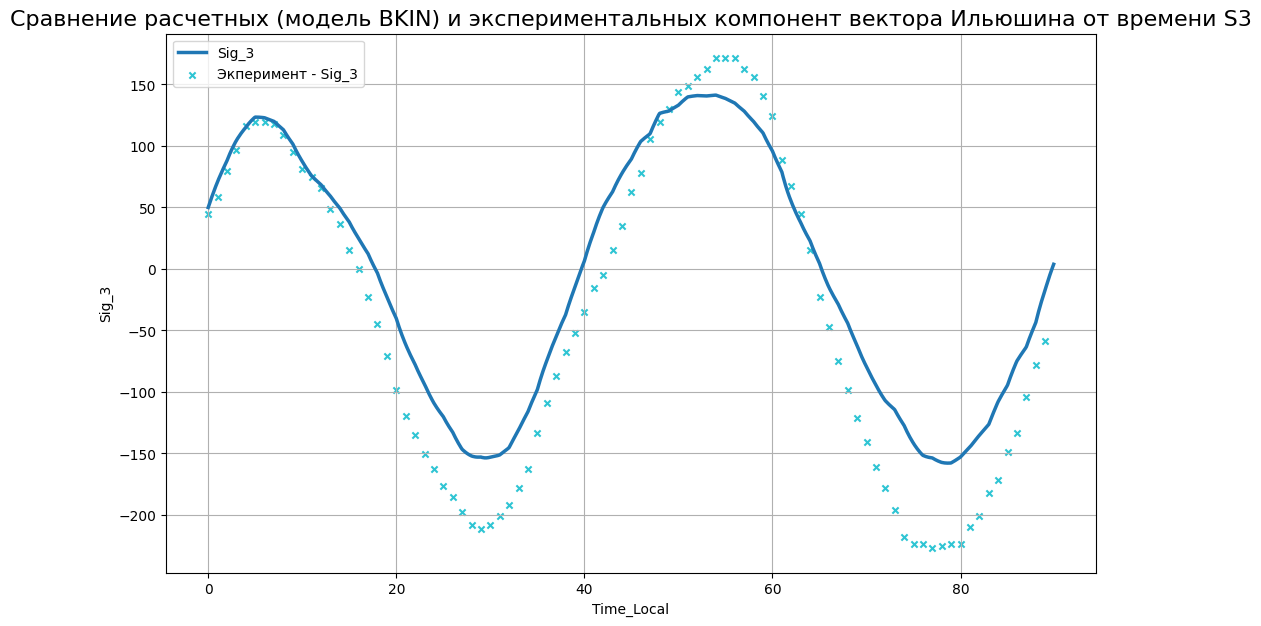

In [7]:
plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_1"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S1",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_2"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S2",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_3"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S3",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

In [8]:
import pandas as pd
import numpy as np

df = pd.merge(numerical_experiment_stage2, df_exp_stage2, on="Time_Local", suffixes=("_mc", "_exp"))

def get_norm(df, s):
    return np.sqrt(df[f"Sig_1{s}"]**2 + df[f"Sig_2{s}"]**2 + df[f"Sig_3{s}"]**2)

norm_mc = get_norm(df, "_mc")
norm_exp = get_norm(df, "_exp")

dot_product = (df["Sig_1_mc"] * df["Sig_1_exp"] + 
               df["Sig_2_mc"] * df["Sig_2_exp"] + 
               df["Sig_3_mc"] * df["Sig_3_exp"])

df["phi"] = np.arccos(np.clip(dot_product / (norm_mc * norm_exp), -1.0, 1.0)) * 180 / np.pi

diff_norm = np.sqrt((df["Sig_1_mc"] - df["Sig_1_exp"])**2 + 
                    (df["Sig_2_mc"] - df["Sig_2_exp"])**2 + 
                    (df["Sig_3_mc"] - df["Sig_3_exp"])**2)

df["relative_error"] = diff_norm / norm_exp

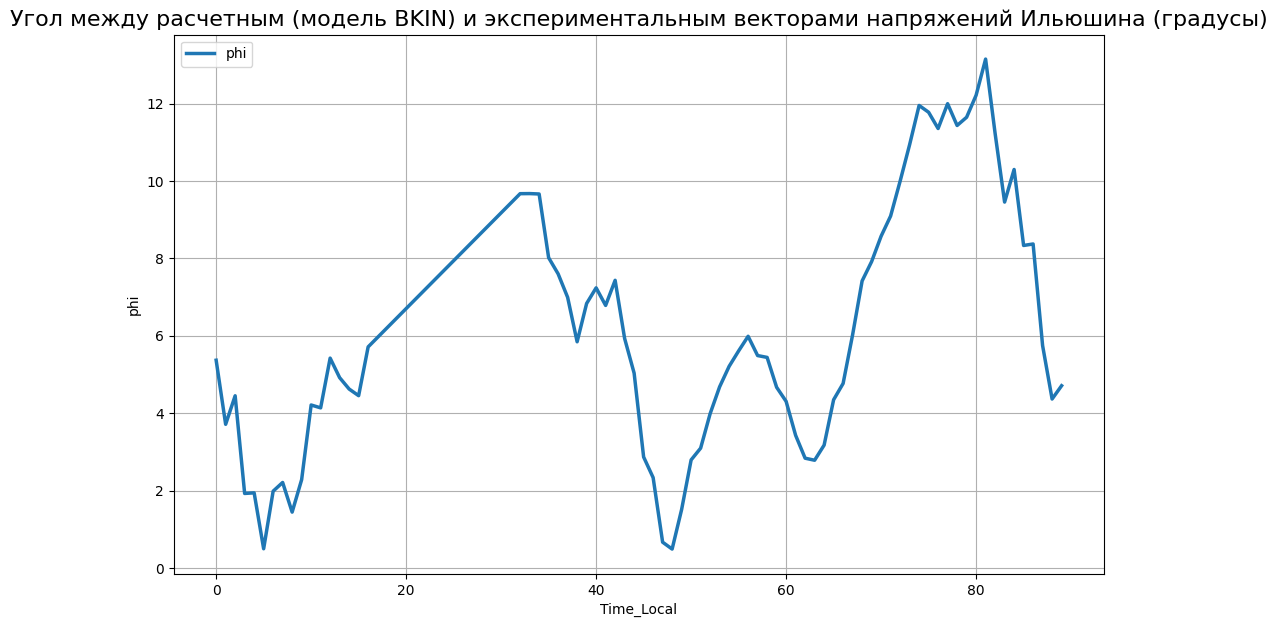

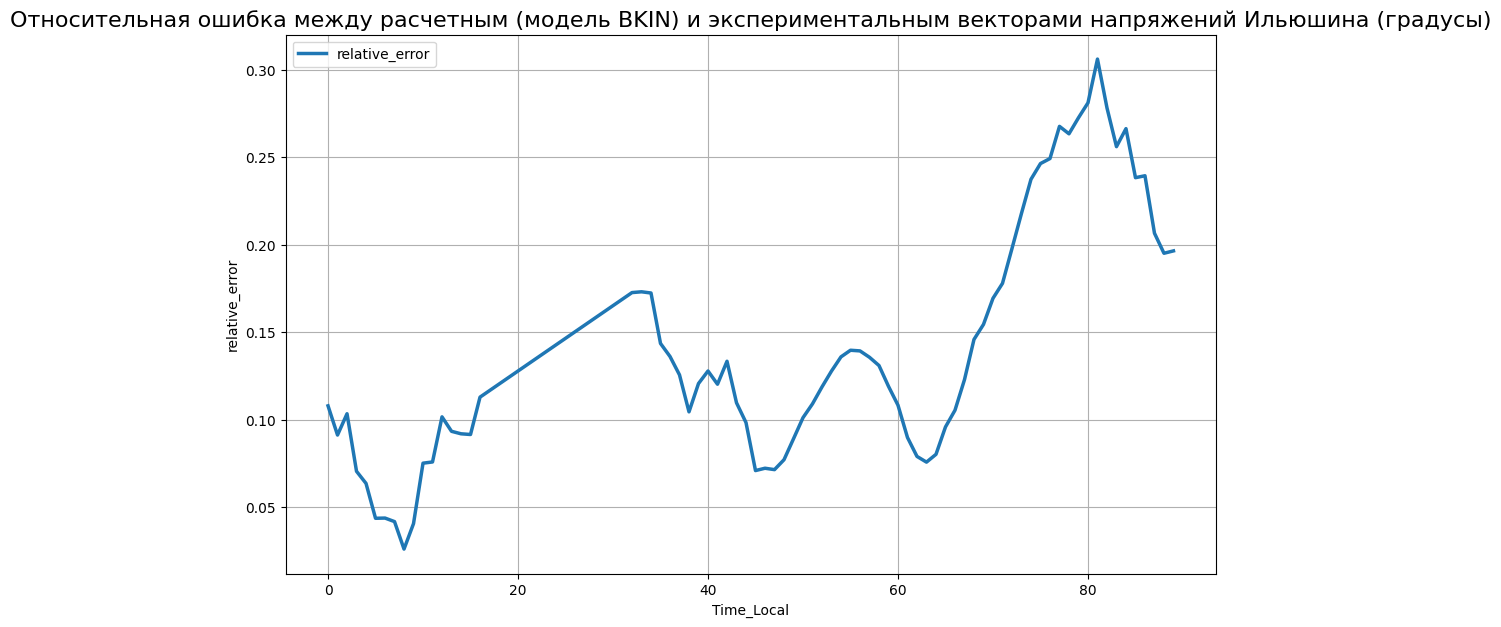

In [9]:
plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["phi"],
    title=f"Угол между расчетным (модель {model_name}) и экспериментальным векторами напряжений Ильюшина (градусы)",
    figsize=(12, 7)
)

plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["relative_error"],
    title=f"Относительная ошибка между расчетным (модель {model_name}) и экспериментальным векторами напряжений Ильюшина (градусы)",
    figsize=(12, 7)
)

#### Выводы по результатам сравнения:
* Наблюдается сильное расхождение в пространстве между поточечными векторами напряжений Ильюшина.
* Максимальное отклонение модуля вектора доходит **0.30**.